<a href="https://colab.research.google.com/github/juliacporto-creator/Estatistica-/blob/main/tarefa11_variaveis_aleatorias_alimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Julia Porto - 17901372

Larissa Mei - 17903839

Marianne Adorno - 17995367

In [ ]:
# =========================================================
# TAREFA 11 — VARIÁVEIS ALEATÓRIAS E PROBABILIDADE
# Aplicações em Ciências dos Alimentos
# =========================================================
# Bibliotecas utilizadas:
# - numpy: geração de números/simulações e cálculos numéricos
# - scipy.stats: funções de probabilidade (Bernoulli, Binomial, Poisson)
# - pandas: organização dos dados em tabelas
# - matplotlib: gráficos de distribuição

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Semente fixa: garante que, sempre que o notebook for executado,
# os resultados "aleatórios" simulados sejam os mesmos (reprodutibilidade)
np.random.seed(42)


## O que esse código faz?
 Carrega as bibliotecas necessárias e traz uma "semente" (seed) para os números aleatórios,garantindo reprodutilidade. Ou seja, assegura que quando o notebook seja rodado, os números simulados sejam sempre os mesmos.

#Variável Aleatória

Uma variável aleatória é uma função que associa um valor numérico a cada possível resultado de um experimento aleatório.

###Considerando na área de Ciências dos Alimentos o seguinte experimento aleatório:

Selecão aleatória de 10 embalagens de um lote de extrato de tomate e a verificação de defeitos.

Sendo:

X = número de embalagens defeituosas encontradas nas 10 embalagens selecionadas

Os possíveis valores de X são:

X = 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10

O resultado a ser obtido depende das embalagens selecionadas e, portanto, não pode ser conhecido com certeza antes da realização do experimento. Nesse caso, X é a variável aleatória que traduz todos os resultados do experimento aleatório em números x
.

A notação usual é, a letra maiúscula X
 representa a variável aleatória, e x
 representa o valor numérico.

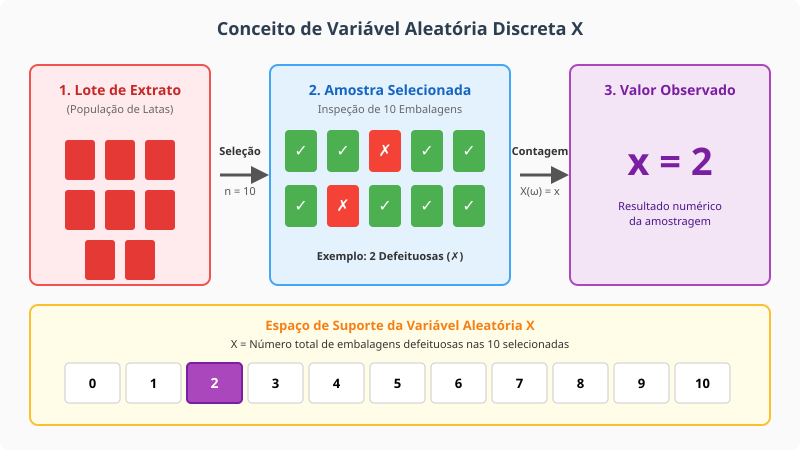

In [ ]:
#@title 📊 Visualizar Diagrama: Variável Aleatória X { display-mode: "form" }
from IPython.display import SVG, display

# Código SVG com tamanho reduzido (width="550") para caber confortavelmente na tela
svg_code = """
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 800 450" width="550">
  <rect width="100%" height="100%" fill="#fafafa" rx="10"/>

  <text x="400" y="35" text-anchor="middle" font-family="sans-serif" font-size="18" font-weight="bold" fill="#2c3e50">Conceito de Variável Aleatória Discreta X</text>

  <g transform="translate(30, 65)">
    <rect width="180" height="220" rx="8" fill="#ffebee" stroke="#ef5350" stroke-width="2"/>
    <text x="90" y="30" text-anchor="middle" font-family="sans-serif" font-size="14" font-weight="bold" fill="#c62828">1. Lote de Extrato</text>
    <text x="90" y="48" text-anchor="middle" font-family="sans-serif" font-size="11" fill="#666">(População de Latas)</text>

    <g transform="translate(25, 65)">
      <rect x="10" y="10" width="30" height="40" rx="3" fill="#e53935"/>
      <rect x="50" y="10" width="30" height="40" rx="3" fill="#e53935"/>
      <rect x="90" y="10" width="30" height="40" rx="3" fill="#e53935"/>
      <rect x="10" y="60" width="30" height="40" rx="3" fill="#e53935"/>
      <rect x="50" y="60" width="30" height="40" rx="3" fill="#e53935"/>
      <rect x="90" y="60" width="30" height="40" rx="3" fill="#e53935"/>
      <rect x="30" y="110" width="30" height="40" rx="3" fill="#e53935"/>
      <rect x="70" y="110" width="30" height="40" rx="3" fill="#e53935"/>
    </g>
  </g>

  <path d="M 220 175 L 260 175" stroke="#555" stroke-width="3" marker-end="url(#arrow)"/>
  <text x="240" y="155" text-anchor="middle" font-family="sans-serif" font-size="11" font-weight="bold" fill="#333">Seleção</text>
  <text x="240" y="195" text-anchor="middle" font-family="sans-serif" font-size="11" fill="#555">n = 10</text>

  <g transform="translate(270, 65)">
    <rect width="240" height="220" rx="8" fill="#e3f2fd" stroke="#42a5f5" stroke-width="2"/>
    <text x="120" y="30" text-anchor="middle" font-family="sans-serif" font-size="14" font-weight="bold" fill="#1565c0">2. Amostra Selecionada</text>
    <text x="120" y="48" text-anchor="middle" font-family="sans-serif" font-size="11" fill="#666">Inspeção de 10 Embalagens</text>

    <g transform="translate(15, 65)">
      <rect x="0" y="0" width="32" height="42" rx="4" fill="#4caf50"/>
      <text x="16" y="26" text-anchor="middle" font-family="sans-serif" font-size="16" fill="#fff">✓</text>
      <rect x="42" y="0" width="32" height="42" rx="4" fill="#4caf50"/>
      <text x="58" y="26" text-anchor="middle" font-family="sans-serif" font-size="16" fill="#fff">✓</text>
      <rect x="84" y="0" width="32" height="42" rx="4" fill="#f44336"/>
      <text x="100" y="26" text-anchor="middle" font-family="sans-serif" font-size="16" fill="#fff">✗</text>
      <rect x="126" y="0" width="32" height="42" rx="4" fill="#4caf50"/>
      <text x="142" y="26" text-anchor="middle" font-family="sans-serif" font-size="16" fill="#fff">✓</text>
      <rect x="168" y="0" width="32" height="42" rx="4" fill="#4caf50"/>
      <text x="184" y="26" text-anchor="middle" font-family="sans-serif" font-size="16" fill="#fff">✓</text>
      <rect x="0" y="55" width="32" height="42" rx="4" fill="#4caf50"/>
      <text x="16" y="81" text-anchor="middle" font-family="sans-serif" font-size="16" fill="#fff">✓</text>
      <rect x="42" y="55" width="32" height="42" rx="4" fill="#f44336"/>
      <text x="58" y="81" text-anchor="middle" font-family="sans-serif" font-size="16" fill="#fff">✗</text>
      <rect x="84" y="55" width="32" height="42" rx="4" fill="#4caf50"/>
      <text x="100" y="81" text-anchor="middle" font-family="sans-serif" font-size="16" fill="#fff">✓</text>
      <rect x="126" y="55" width="32" height="42" rx="4" fill="#4caf50"/>
      <text x="142" y="81" text-anchor="middle" font-family="sans-serif" font-size="16" fill="#fff">✓</text>
      <rect x="168" y="55" width="32" height="42" rx="4" fill="#4caf50"/>
      <text x="184" y="81" text-anchor="middle" font-family="sans-serif" font-size="16" fill="#fff">✓</text>
    </g>
    <text x="120" y="195" text-anchor="middle" font-family="sans-serif" font-size="11" font-weight="bold" fill="#333">Exemplo: 2 Defeituosas (✗)</text>
  </g>

  <path d="M 520 175 L 560 175" stroke="#555" stroke-width="3" marker-end="url(#arrow)"/>
  <text x="540" y="155" text-anchor="middle" font-family="sans-serif" font-size="11" font-weight="bold" fill="#333">Contagem</text>
  <text x="540" y="195" text-anchor="middle" font-family="sans-serif" font-size="11" fill="#555">X(ω) = x</text>

  <g transform="translate(570, 65)">
    <rect width="200" height="220" rx="8" fill="#f3e5f5" stroke="#ab47bc" stroke-width="2"/>
    <text x="100" y="30" text-anchor="middle" font-family="sans-serif" font-size="14" font-weight="bold" fill="#7b1fa2">3. Valor Observado</text>
    <text x="100" y="110" text-anchor="middle" font-family="sans-serif" font-size="38" font-weight="bold" fill="#7b1fa2">x = 2</text>
    <text x="100" y="145" text-anchor="middle" font-family="sans-serif" font-size="11" fill="#4a148c">Resultado numérico</text>
    <text x="100" y="160" text-anchor="middle" font-family="sans-serif" font-size="11" fill="#4a148c">da amostragem</text>
  </g>

  <g transform="translate(30, 305)">
    <rect width="740" height="120" rx="8" fill="#fffde7" stroke="#fbc02d" stroke-width="2"/>
    <text x="370" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold" fill="#f57f17">Espaço de Suporte da Variável Aleatória X</text>
    <text x="370" y="43" text-anchor="middle" font-family="sans-serif" font-size="11" fill="#333">X = Número total de embalagens defeituosas nas 10 selecionadas</text>

    <g transform="translate(35, 58)">
      <rect x="0" y="0" width="55" height="40" rx="4" fill="#fff" stroke="#ccc"/>
      <text x="27.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold">0</text>
      <rect x="61" y="0" width="55" height="40" rx="4" fill="#fff" stroke="#ccc"/>
      <text x="88.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold">1</text>
      <rect x="122" y="0" width="55" height="40" rx="4" fill="#ab47bc" stroke="#7b1fa2" stroke-width="2"/>
      <text x="149.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="14" font-weight="bold" fill="#fff">2</text>
      <rect x="183" y="0" width="55" height="40" rx="4" fill="#fff" stroke="#ccc"/>
      <text x="210.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold">3</text>
      <rect x="244" y="0" width="55" height="40" rx="4" fill="#fff" stroke="#ccc"/>
      <text x="271.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold">4</text>
      <rect x="305" y="0" width="55" height="40" rx="4" fill="#fff" stroke="#ccc"/>
      <text x="332.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold">5</text>
      <rect x="366" y="0" width="55" height="40" rx="4" fill="#fff" stroke="#ccc"/>
      <text x="393.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold">6</text>
      <rect x="427" y="0" width="55" height="40" rx="4" fill="#fff" stroke="#ccc"/>
      <text x="454.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold">7</text>
      <rect x="488" y="0" width="55" height="40" rx="4" fill="#fff" stroke="#ccc"/>
      <text x="515.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold">8</text>
      <rect x="549" y="0" width="55" height="40" rx="4" fill="#fff" stroke="#ccc"/>
      <text x="576.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold">9</text>
      <rect x="610" y="0" width="55" height="40" rx="4" fill="#fff" stroke="#ccc"/>
      <text x="637.5" y="25" text-anchor="middle" font-family="sans-serif" font-size="13" font-weight="bold">10</text>
    </g>
  </g>

  <defs>
    <marker id="arrow" viewBox="0 0 10 10" refX="5" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
      <path d="M 0 0 L 10 5 L 0 10 z" fill="#555"/>
    </marker>
  </defs>
</svg>
"""

display(SVG(svg_code))

#Variável aleatória discreta
aquela que os resultados são frutos de contagem, assumindo valores isolados e contáveis, geralmente inteiros.

####Exemplos:
- quantidade de embalagens defeituosas em um lote;
- quantidade de produtos contaminados em um lote;
- quantidade de produtos produzidos em uma fábrica em um turno.

Em todos os exemplos os resultados são contados: número de embalagens, número de produtos contaminados e número de produtos produzidos.

#Variável aleatória contínua
aquela que os resultados são frutos de mensuração, assumindo qualquer valor dentro de determinado intervalo, incluindo valores decimais.

####Exemplos:
- quantidade de molho de tomate;
- teor de umidade em um alimento;
- temperatura de armazenamento de um alimento.

Em todos os exemplos os resultados são frutos de mensuração e assumem valores dentro de um determinado intervalo, incluindo decimais: quantidade em massa de molho de tomate, quantidade em % de umidade e temperatura em °C.

=== Exemplos de variáveis DISCRETAS ===
- Nº de embalagens defeituosas em um lote
  Justificativa: contagem de itens (0,1,2,...)
- Nº de frutas danificadas em uma caixa
  Justificativa: contagem de itens (0,1,2,...)
- Nº de reclamações de consumidores por dia
  Justificativa: contagem de eventos no tempo

=== Exemplos de variáveis CONTÍNUAS (dados reais de artigo) ===
                 alimento  umidade_pct    pH
0      Biscoito chocolate         1.95  6.99
1        Biscoito morango         2.35  6.59
2  Biscoito cream cracker         1.83  6.60
3        Farinha de milho         6.00  5.80
4        Geleia de goiaba        26.32  4.03
5           Banana nanica        67.80  4.98
6              Ovo cozido        77.26  8.15

Umidade (%): média = 26.22, desvio-padrão = 32.91
pH: média = 6.16, desvio-padrão = 1.36


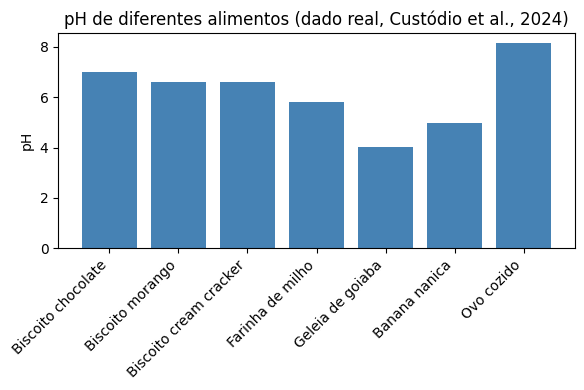

In [ ]:
# ---------------------------------------------------------
# SEÇÃO 2 — Variáveis discretas e contínuas
# ---------------------------------------------------------

# --- Exemplos DISCRETOS (apenas ilustração conceitual) ---
discretas = {
    "Nº de embalagens defeituosas em um lote": "contagem de itens (0,1,2,...)",
    "Nº de frutas danificadas em uma caixa": "contagem de itens (0,1,2,...)",
    "Nº de reclamações de consumidores por dia": "contagem de eventos no tempo"
}

print("=== Exemplos de variáveis DISCRETAS ===")
for var, motivo in discretas.items():
    print(f"- {var}\n  Justificativa: {motivo}")

# --- Exemplos CONTÍNUOS com DADOS REAIS ---
# Fonte: CUSTÓDIO, SILVA e BATTESTIN (2024). Avaliação da composição
# centesimal de produtos alimentícios. Scientia Vitae, v.18, n.46.
# Dados extraídos da Tabela 1 do artigo (valores médios medidos em laboratório).
dados_reais = pd.DataFrame({
    "alimento": ["Biscoito chocolate", "Biscoito morango", "Biscoito cream cracker",
                 "Farinha de milho", "Geleia de goiaba", "Banana nanica", "Ovo cozido"],
    "umidade_pct": [1.95, 2.35, 1.83, 6.00, 26.32, 67.80, 77.26],
    "pH": [6.99, 6.59, 6.60, 5.80, 4.03, 4.98, 8.15]
})

print("\n=== Exemplos de variáveis CONTÍNUAS (dados reais de artigo) ===")
print(dados_reais)
print(f"\nUmidade (%): média = {dados_reais['umidade_pct'].mean():.2f}, "
      f"desvio-padrão = {dados_reais['umidade_pct'].std():.2f}")
print(f"pH: média = {dados_reais['pH'].mean():.2f}, "
      f"desvio-padrão = {dados_reais['pH'].std():.2f}")

# Gráfico simples para visualizar a variação de uma grandeza contínua (pH)
plt.figure(figsize=(6,4))
plt.bar(dados_reais["alimento"], dados_reais["pH"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("pH")
plt.title("pH de diferentes alimentos (dado real, Custódio et al., 2024)")
plt.tight_layout()
plt.show()

##O que esse código faz?
 organiza os seis exemplos pedidos (3 discretos + 3 contínuos) com a justificativa da classificação. Para as variáveis contínuas, em vez de inventar números, usamos a tabela de dados realmente medida no artigo de Custódio, Silva e Battestin (2024) — pH e umidade de 7 alimentos — calcula média/desvio-padrão e plota um gráfico de barras mostrando a variação do pH entre os produtos.

##Modelo de Bernoulli


O trabalho analisou 6 amostras de leite cru que foram armazenadas a 25°C. A CBT foi analisada durante diferentes períodos de armazenamento.

A dissertação informa que o limite máximo de CBT estabelecido na IN nº 62 era 300.000 UFC/mL.


Nesse exemplo, foram utilizados os seis valores de CTB para a temperatura de 25°C.

- 1 (sucesso): CBT dentro do limite de 300.000 UFC/mL.
- 0 (fracasso): CBT acima do limite.
Foram observados 2 sucessos e 4 fracassos.
A probabilidade observada de sucesso foi:
$$ P(S)=\frac{2}{6}=0,3333 $$

ou seja, 33,33% dos resultados analisados estavam dentro do limite estabelecido.

Fonte: https://files.cercomp.ufg.br/weby/up/67/o/Dissertacao2015_Thamara_Venancio.pdf

In [ ]:
import numpy as np

#dados para 25°C
cbt = [4.2309, 5.4430, 6.7217, 6.8380, 6.9187, 7.2322]

#limite: 300.000 UFC/mL = 5,4771 log UFC/mL
limite = 5.4771

#converter cbt para um array NumPy antes da comparação
cbt_array = np.array(cbt)

# 1 = sucesso (dentro do limite)
# 0 = fracasso (acima do limite)
bernoulli = (cbt_array <= limite).astype(int)

print("Resultados:", bernoulli)
print("Sucessos:", bernoulli.sum())
print("Fracassos:", len(bernoulli) - bernoulli.sum())
print("Probabilidade de sucesso:", bernoulli.mean())

Resultados: [1 1 0 0 0 0]
Sucessos: 2
Fracassos: 4
Probabilidade de sucesso: 0.3333333333333333


##Modelo Binomial

Em uma situação hipotética, deseja verificar se a fermentação ocorre adequadamente. Após produção de pães, são selecionados 30 de forma aleatória para avaliação do volume

Para cada pão existem dois resultados:

- Sucesso: o pão apresenta volume adequado após a fermentação
- Fracasso: o pão apresenta volume inadequado

Suponha que, com base em avaliações anteriores, a probabilidade de um pão apresentar volume adequado seja de 90%

O exemplo apresenta as principais características necessárias:

1. Número fixo de observações: serão avaliados exatamente 30 pães.

2. Dois resultados possíveis: cada pão pode ter volume adequado ou inadequado.

3. Probabilidade de sucesso definida: a probabilidade de um pão apresentar volume adequado é \(p=0,90\).

4. Independência: considera-se que o resultado de um pão não interfere no resultado dos demais.

In [ ]:
print("Qual é a probabilidade de exatamente 27 dos 30 pães apresentarem volume adequado?")

from math import comb
#quantidade de pães
n = 30
#probabilidade de um pão apresentar volume adequado
p = 0.90
#quantidade de pães que apresentaram volume adequado
k = 27

#probabilidade de 27 dos 30 pães apresentarem volume adequado
probabilidade = comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

print("\nProbabilidade:", probabilidade)
print("Porcentagem:", probabilidade * 100, "%")

Qual é a probabilidade de exatamente 27 dos 30 pães apresentarem volume adequado?

Probabilidade: 0.23608793223234262
Porcentagem: 23.60879322323426 %


Isso significa que, considerando 30 pães, uma probabilidade de 90% de cada pão apresentar volume adequado e as observações como independentes, a probabilidade de encontrar exatamente 27 pães com volume adequado é de aproximadamente 23,6%.

#Modelo de Poisson
O modelo de Poisson representa a contagem de ocorrências de um evento em um intervalo de tempo, espaço, área, volume ou unidade de produção, quando os eventos ocorrem de forma independente e a uma taxa média conhecida (λ).

Base científica: a literatura de microbiologia de alimentos utiliza classicamente a distribuição de Poisson para modelar a contagem de colônias em placa (unidades formadoras de colônias, UFC), pois a distribuição espacial de micro-organismos em uma amostra homogênea segue, em teoria, um processo de Poisson (SUN; KUROSU; SHINTANI, 2006). O procedimento de contagem em placa descrito por Dorigon, Duarte e Carneiro (2017) para amostras de milho triturado é um exemplo desse tipo de contagem.

Importante (honestidade científica): Jongenburger et al. (2012) mostram que, na prática, quando a contaminação é heterogênea (não distribuída uniformemente no lote), a Poisson pode se ajustar mal aos dados reais, sendo necessários modelos alternativos (como a Binomial Negativa). Isso não invalida o uso didático da Poisson aqui — apenas indica que ela representa o cenário ideal de contaminação homogênea, que é a premissa teórica do modelo.

Dado simulado: o valor de λ abaixo é simulado, escolhido dentro da faixa de contagem tipicamente utilizada em controle de qualidade microbiológico (poucas dezenas de UFC por placa após diluição adequada), inspirado na ordem de grandeza discutida nos artigos citados.

Taxa média (lambda) = 8 colônias por placa
Variância = média para Poisson: 8.0

P(X = 10 colônias) = 0.0993
P(X > 15 colônias, acima do limite de qualidade) = 0.0082

Contagens simuladas em 30 placas: [ 6  7  6  7  7  6 11  4  8  6  6 12  2  8 12  5  7  8  6 11  6  8  9 11
  5  9  8  9  8 12]
Média observada na simulação: 7.67


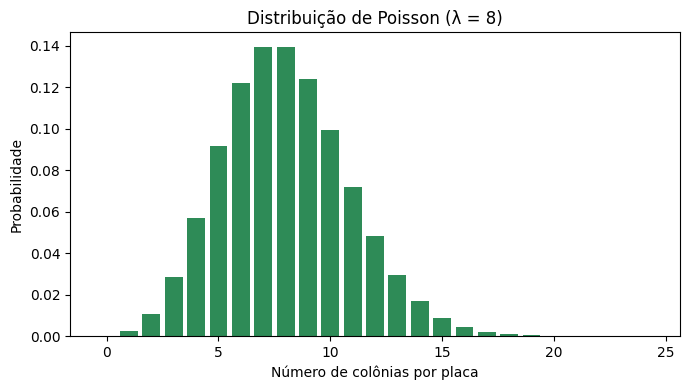

In [ ]:
# ---------------------------------------------------------
# SEÇÃO 5 — Modelo de Poisson
# ---------------------------------------------------------
# SIMULAÇÃO IDENTIFICADA: lambda (taxa média de colônias por placa)
# foi definido de forma ilustrativa, dentro da faixa usual de contagem
# em controle microbiológico de alimentos.
# Base conceitual real: SUN; KUROSU; SHINTANI (2006); DORIGON et al. (2017).

lambda_colonias = 8  # média de 8 UFC por placa (valor simulado, ilustrativo)

poisson_dist = stats.poisson(lambda_colonias)

print(f"Taxa média (lambda) = {lambda_colonias} colônias por placa")
print(f"Variância = média para Poisson: {poisson_dist.var():.1f}")

# Probabilidade de encontrar exatamente 10 colônias na placa
p_10 = poisson_dist.pmf(10)
print(f"\nP(X = 10 colônias) = {p_10:.4f}")

# Probabilidade de a placa exceder o limite de qualidade (ex.: mais de 15 colônias)
p_acima_15 = poisson_dist.sf(15)
print(f"P(X > 15 colônias, acima do limite de qualidade) = {p_acima_15:.4f}")

# Simulação de 30 placas analisadas em um mesmo lote
placas_simuladas = poisson_dist.rvs(size=30)
print(f"\nContagens simuladas em 30 placas: {placas_simuladas}")
print(f"Média observada na simulação: {placas_simuladas.mean():.2f}")

# Gráfico da distribuição de Poisson
x = np.arange(0, 25)
plt.figure(figsize=(7,4))
plt.bar(x, poisson_dist.pmf(x), color="seagreen")
plt.xlabel("Número de colônias por placa")
plt.ylabel("Probabilidade")
plt.title(f"Distribuição de Poisson (λ = {lambda_colonias})")
plt.tight_layout()
plt.show()

##O que esse código faz?
 Cria uma distribuição de Poisson com stats.poisson(lambda). Calcula a probabilidade de contagens específicas (pmf) e a probabilidade de ultrapassar um limite (sf, survival function). Depois, .rvs(size=30) simula 30 placas de contagem microbiológica, mostrando como a contagem varia mesmo mantendo a mesma taxa média — essa variação em torno de λ caracteriza o processo de Poisson.

=== Comparação dos modelos probabilísticos ===

   Modelo                                      Tipo de fenômeno                       Valores possíveis                                      Quando aplicar                Exemplo em Ciências dos Alimentos
Bernoulli         Um único ensaio com dois resultados possíveis                                  0 ou 1                        Uma única observação binária        Consumidor aprova ou não a trufa (p=0,84)
 Binomial     Nº de sucessos em n ensaios fixos e independentes                         0, 1, 2, ..., n           n observações binárias repetidas, mesma p Nº de consumidores que aprovam em 100 avaliações
  Poisson Nº de ocorrências em um intervalo (tempo/espaço/lote) 0, 1, 2, ... (sem limite superior fixo) Contagem de eventos raros/independentes por unidade    Nº de colônias microbianas contadas por placa


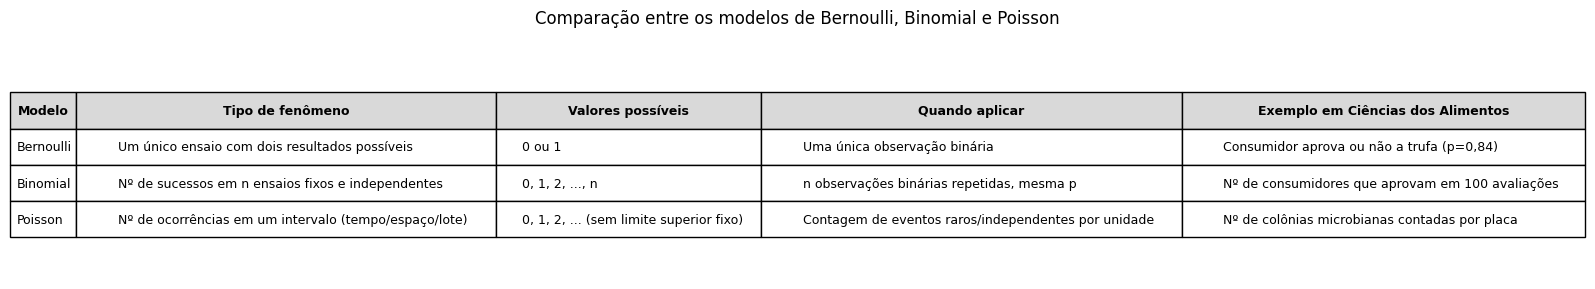


Imagem salva como 'comparacao_modelos.png'


In [ ]:
# ---------------------------------------------------------
# SEÇÃO 6 — Comparação entre Bernoulli, Binomial e Poisson (em tabela)
# ---------------------------------------------------------

comparacao = pd.DataFrame({
    "Modelo": ["Bernoulli", "Binomial", "Poisson"],
    "Tipo de fenômeno": [
        "Um único ensaio com dois resultados possíveis",
        "Nº de sucessos em n ensaios fixos e independentes",
        "Nº de ocorrências em um intervalo (tempo/espaço/lote)"
    ],
    "Valores possíveis": [
        "0 ou 1",
        "0, 1, 2, ..., n",
        "0, 1, 2, ... (sem limite superior fixo)"
    ],
    "Quando aplicar": [
        "Uma única observação binária",
        "n observações binárias repetidas, mesma p",
        "Contagem de eventos raros/independentes por unidade"
    ],
    "Exemplo em Ciências dos Alimentos": [
        "Consumidor aprova ou não a trufa (p=0,84)",
        "Nº de consumidores que aprovam em 100 avaliações",
        "Nº de colônias microbianas contadas por placa"
    ]
})

# --- Versão 1: tabela impressa no terminal ---
print("=== Comparação dos modelos probabilísticos ===\n")
print(comparacao.to_string(index=False))

# --- Versão 2: tabela como imagem (matplotlib), útil para README/relatório ---
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")  # remove os eixos, sobra só a tabela

tabela_plot = ax.table(
    cellText=comparacao.values,
    colLabels=comparacao.columns,
    cellLoc="left",
    loc="center"
)

tabela_plot.auto_set_font_size(False)
tabela_plot.set_fontsize(9)
tabela_plot.auto_set_column_width(col=list(range(len(comparacao.columns))))
tabela_plot.scale(1, 2.2)  # aumenta a altura das linhas para melhor leitura

# Estiliza o cabeçalho (linha 0) em negrito e com fundo cinza
for col in range(len(comparacao.columns)):
    tabela_plot[(0, col)].set_text_props(weight="bold")
    tabela_plot[(0, col)].set_facecolor("#d9d9d9")

plt.title("Comparação entre os modelos de Bernoulli, Binomial e Poisson", pad=20)
plt.tight_layout()
plt.savefig("comparacao_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nImagem salva como 'comparacao_modelos.png'")

##O que esse código faz?
 monta uma tabela-resumo (impressa no terminal) comparando os três modelos quanto ao tipo de fenômeno, valores possíveis, situação de aplicação e um exemplo contextualizado, exatamente como pedido no enunciado.

Referências bibliográficas:

ZIBETTI, André Wüst. *Variáveis aleatórias*. Florianópolis: Universidade Federal de Santa Catarina, [s.d.]. Disponível em: https://www.inf.ufsc.br/~andre.zibetti/probabilidade/variaveis_aleatorias.html. Acesso em: 26 set. 2026.

MONTGOMERY, Douglas C.; RUNGER, George C. Estatística Aplicada e Probabilidade para Engenheiros.

MAURÍCIO, A. A.; TRENTINALHA, A. S. Elaboração e análise sensorial de trufa isenta de lactose. Acta Scientiarum. Health Sciences, v. 32, n. 1, p. 85-91, 2010. Disponível em: https://doaj.org/article/87eb27bbbfbe48ce9273e480dd3a4f47
CUSTÓDIO, S. de F. P.; SILVA, S. de B.; BATTESTIN, V. Avaliação da composição centesimal de produtos alimentícios. Scientia Vitae, v. 18, n. 46, p. 35-46, 2024. Disponível em: https://revistaifspsr.com/v18n46_3546.pdf

ANJOS, R. F. dos. Estudo sobre a perda da hermeticidade de embalagens plásticas flexíveis utilizadas no envase de carne bovina cozida e desidratada (Beef Jerky). Dissertação (Mestrado) — FZEA, Universidade de São Paulo, Pirassununga, 2017. DOI: 10.11606/D.74.2018.tde-20062018-153458

DORIGON, F. G.; DUARTE, R. B.; CARNEIRO, A. S. Determinação da contagem global de microrganismo mesófilos aeróbios em amostra de milho (Zea mays, L) triturado. Unifimes, 2017. Disponível em: https://publicacoes.unifimes.edu.br/index.php/coloquio/article/view/342

SUN, X.; KUROSU, S.; SHINTANI, H. The Expanded Application of Most Probable Number to the Quantitative Evaluation of Extremely Low Microbial Count. PDA Journal of Pharmaceutical Science and Technology, v. 60, n. 2, p. 124-134, 2006.

JONGENBURGER, I.; REIJ, M. W.; BOER, E. P. J.; ZWIETERING, M. H.; GORRIS, L. G. M. Modelling homogeneous and heterogeneous microbial contaminations in a powdered food product. International Journal of Food Microbiology, v. 157, n. 1, p. 35-44, 2012. DOI: 10.1016/j.ijfoodmicro.2012.04.009

ROSS, S. A First Course in Probability (apoio conceitual sobre variáveis aleatórias).

## README.md

# TAREFA 11 — Variáveis Aleatórias e Probabilidade: Aplicações em Ciências dos Alimentos

## Integrantes:
 -Julia Porto ( Descrição dos conceitos de variáveis)

 -Larissa Mei (Explicação do Modelo de Bernoulli e binomial)

-Marianne Adorno ( Explicação do modelo de Poisson e geração de gráficos/tabela)

Este notebook explora os conceitos de variáveis aleatórias discretas e contínuas, além de apresentar e comparar três modelos probabilísticos fundamentais (Bernoulli, Binomial e Poisson) com aplicações e exemplos práticos na área de Ciências dos Alimentos.

## Seções do Notebook:

### 1. Inicialização e Configuração
Carrega as bibliotecas necessárias para análise de dados e estatística (NumPy, Pandas, Matplotlib, SciPy) e define uma semente para reprodutibilidade de simulações.

### 2. Conceito de Variável Aleatória
Explica o que é uma variável aleatória, utilizando um exemplo de inspeção de embalagens de extrato de tomate para ilustrar a conversão de resultados de experimentos aleatórios em valores numéricos. Inclui um diagrama visual para clarear o conceito.

### 3. Variáveis Aleatórias Discretas e Contínuas
Define e exemplifica a diferença entre variáveis aleatórias discretas (resultados de contagem, como número de embalagens defeituosas) e contínuas (resultados de mensuração, como teor de umidade ou pH). Apresenta dados reais de pH de alimentos e um gráfico para ilustrar as variáveis contínuas.

### 4. Modelo de Bernoulli
Introduz o modelo de Bernoulli, que descreve experimentos com apenas dois resultados possíveis (sucesso/fracasso). Um exemplo prático de teste de vazamento em garrafas é simulado para demonstrar a aplicação.

### 5. Modelo Binomial
Aborda o modelo Binomial, que calcula a probabilidade de um número específico de sucessos em um número fixo de ensaios independentes. É exemplificado com a avaliação do volume de pães após a fermentação.

### 6. Modelo de Poisson
Explora o modelo de Poisson, ideal para a contagem de ocorrências de eventos raros em um intervalo fixo (tempo, espaço, volume). O notebook utiliza um exemplo de contagem de colônias microbianas em placas, um cenário comum na microbiologia de alimentos. Simula contagens e visualiza a distribuição.

### 7. Comparação entre Bernoulli, Binomial e Poisson
Apresenta uma tabela comparativa detalhada dos três modelos probabilísticos, destacando o tipo de fenômeno, valores possíveis, situações de aplicação e exemplos contextualizados em Ciências dos Alimentos. A tabela é exibida tanto no console quanto como uma imagem gerada graficamente.

## Bibliotecas Utilizadas:

*   **`numpy`**: Para geração de números aleatórios, simulações e cálculos numéricos.
*   **`pandas`**: Para organização e manipulação de dados em DataFrames.
*   **`matplotlib`**: Para visualização gráfica de distribuições e dados.
*   **`scipy.stats`**: Para funções de probabilidade e distribuições estatísticas (Bernoulli, Binomial, Poisson).
*   **`IPython.display`**: Para exibir conteúdo como SVG no notebook.

## Autores:

*   Julia Porto - 17901372
*   Larissa Mei - 17903839
*   Marianne Adorno - 17995367
